# 03 — Detecção de sinais por disproporcionalidade

**Coração do projeto.** Calcula PRR, ROR e IC para todos os pares droga × reação do FAERS 2023.

## Roteiro
1. Construir tabela analítica (caso × droga × reação) com PS apenas
2. Excluir reações não-clínicas (off-label use, ineffective, etc.)
3. Calcular PRR + ROR + IC (com IC 95%)
4. **Validação:** sinais conhecidos aparecem?
5. **Descoberta:** top sinais novos por IC025
6. Salvar resultados para o dashboard

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import (
    dedupe_demo, normalize_age, normalize_drug_table, build_long
)
from src.signals import compute_all

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

PROCESSED = Path.cwd().parent / "data" / "processed"
FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Construir tabela analítica

Cada linha = (caso, droga PS, reação). Usamos `build_long()` do `src.preprocess`.

In [2]:
demo = pd.read_parquet(PROCESSED / "demo_2023.parquet")
drug = pd.read_parquet(PROCESSED / "drug_2023.parquet")
reac = pd.read_parquet(PROCESSED / "reac_2023.parquet")
outc = pd.read_parquet(PROCESSED / "outc_2023.parquet")

demo = normalize_age(dedupe_demo(demo))
drug_n = normalize_drug_table(drug)

print(f"DEMO dedup: {len(demo):,}  |  DRUG normalizado: {len(drug_n):,}  |  REAC: {len(reac):,}")

DEMO dedup: 1,544,991  |  DRUG normalizado: 7,470,835  |  REAC: 5,843,817


In [3]:
long = build_long(demo, drug_n, reac, outc, only_primary_suspect=True)
print(f"Tabela long (caso × droga PS × reação): {len(long):,} linhas")
print(f"  - drogas únicas: {long['drug'].nunique():,}")
print(f"  - reações únicas: {long['reaction'].nunique():,}")
print(f"  - casos únicos: {long['caseid'].nunique():,}")
long.head(5)

Tabela long (caso × droga PS × reação): 5,799,620 linhas
  - drogas únicas: 3,065


  - reações únicas: 16,410


  - casos únicos: 1,543,135


,caseid,drug,reaction,primaryid,age_years,sex,serious,death,hospitalization,outcomes
0,10016781,OCTREOTIDE ACETATE,INJECTION SITE MASS,1001678124,56.0,F,False,False,False,OT
1,10016781,OCTREOTIDE ACETATE,INJECTION SITE MASS,1001678124,56.0,F,False,False,False,OT
2,10016781,OCTREOTIDE ACETATE,INJECTION SITE MASS,1001678124,56.0,F,False,False,False,OT
3,10016781,OCTREOTIDE ACETATE,INJECTION SITE MASS,1001678124,56.0,F,False,False,False,OT
4,10016781,OCTREOTIDE ACETATE,BLOOD CREATINE INCREASED,1001678124,56.0,F,False,False,False,OT


## 2. Excluir reações não-clínicas (Product Use Issues)

Termos como `OFF LABEL USE` ou `DRUG INEFFECTIVE` são *issues de uso*, não reações farmacológicas. Inflacionam os totais e poluem os sinais.

In [4]:
NON_CLINICAL = {
    "OFF LABEL USE", "DRUG INEFFECTIVE", "PRODUCT USE ISSUE",
    "PRODUCT DOSE OMISSION ISSUE", "INAPPROPRIATE SCHEDULE OF PRODUCT ADMINISTRATION",
    "WRONG DRUG ADMINISTERED", "NO ADVERSE EVENT", "PRODUCT QUALITY ISSUE",
    "MEDICATION ERROR", "INCORRECT DOSE ADMINISTERED",
    "ACCIDENTAL EXPOSURE TO PRODUCT", "WRONG TECHNIQUE IN PRODUCT USAGE PROCESS",
    "INTENTIONAL OVERDOSE", "PRODUCT SUBSTITUTION ISSUE",
    "DRUG DOSE OMISSION", "WRONG PATIENT RECEIVED PRODUCT",
    "DRUG ABUSE", "DRUG ABUSER", "INTENTIONAL PRODUCT MISUSE",
}

before = len(long)
long = long[~long["reaction"].isin(NON_CLINICAL)].copy()
removed = before - len(long)
print(f"Removidas {removed:,} linhas com termos não-clínicos ({removed/before*100:.1f}%)")
print(f"Tabela final: {len(long):,} linhas")

Removidas 462,034 linhas com termos não-clínicos (8.0%)
Tabela final: 5,337,586 linhas


## 3. Calcular sinais (PRR + ROR + IC)

Filtro `a >= 3` (padrão FDA) já aplicado no `build_2x2`.

In [5]:
%time signals = compute_all(long, drug_col="drug", reac_col="reaction", min_reports=3)
print(f"\nPares droga–reação avaliados: {len(signals):,}")
print(f"Sinais positivos (PRR): {signals['prr_signal'].sum():,}")
print(f"Sinais positivos (ROR): {signals['ror_signal'].sum():,}")
print(f"Sinais positivos (IC):  {signals['ic_signal'].sum():,}")
print(f"Sinais em pelo menos um critério: {signals['any_signal'].sum():,}")

CPU times: total: 1.86 s
Wall time: 1.89 s

Pares droga–reação avaliados: 251,759
Sinais positivos (PRR): 121,607
Sinais positivos (ROR): 133,137
Sinais positivos (IC):  43,693
Sinais em pelo menos um critério: 134,513


In [6]:
signals.describe().round(3)

,a,b,c,d,n,prr,prr_ci_low,prr_ci_high,chi2,ror,ror_ci_low,ror_ci_high,ic,ic_ci_low,ic_ci_high
count,251759.000,251759.000,251759.000,251759.000,251759.0,251759.000,251521.000,251759.000,251759.000,251514.000,251514.000,251514.000,251759.000,251759.000,251759.000
mean,18.999,18968.530,7362.329,5311236.143,5337586.0,inf,21.218,inf,482.358,66.053,21.898,267.665,1.070,-1.035,3.175
std,106.688,30043.693,12593.339,30240.558,0.0,NaN,453.501,NaN,10308.476,2433.151,527.229,17798.671,1.641,1.275,2.402
min,3.000,0.000,0.000,5098523.000,5337586.0,0.005,0.002,0.010,0.000,0.005,0.002,0.010,-7.584,-8.696,-6.472
25%,4.000,2557.000,590.000,5305103.500,5337586.0,0.953,0.439,1.974,1.824,0.952,0.439,1.975,-0.065,-1.697,1.323
50%,6.000,7220.000,2282.000,5322346.000,5337586.0,2.366,1.116,5.134,10.936,2.365,1.115,5.143,1.085,-1.153,2.960
75%,12.000,19227.000,8108.000,5329814.000,5337586.0,7.881,3.625,17.945,54.064,7.880,3.627,17.997,2.280,-0.368,5.032
max,20168.000,160729.000,79633.000,5337554.000,5337586.0,inf,75805.288,inf,1590552.015,814197.508,101543.091,6528436.137,9.792,7.507,12.529


## 4. Validação — sinais conhecidos aparecem?

Vamos verificar associações **bem documentadas** na literatura:
- **Warfarin → hemorragia/sangramento**
- **Estatinas → mialgia/rabdomiólise**
- **Metformin → acidose láctica**
- **Opioides → depressão respiratória**
- **Bisfosfonatos → osteonecrose mandibular**

In [7]:
def check_signal(drug_pat: str, reac_pat: str, top: int = 5):
    """Procura pares de droga e reação contendo os padrões dados."""
    sub = signals[
        signals["drug"].str.contains(drug_pat.upper(), na=False)
        & signals["reaction"].str.contains(reac_pat.upper(), na=False)
    ].sort_values("ic", ascending=False).head(top)
    cols = ["drug", "reaction", "a", "prr", "ic", "ic_ci_low", "any_signal"]
    return sub[cols].round(2)

print("=== WARFARIN → SANGRAMENTO ===")
display(check_signal("WARFARIN", "HAEMORRHAGE"))

print("\n=== ESTATINAS (atorvastatin/simvastatin) → MIALGIA ===")
display(check_signal("STATIN", "MYALGIA"))

print("\n=== METFORMIN → ACIDOSE LÁCTICA ===")
display(check_signal("METFORMIN", "LACTIC ACIDOSIS"))

print("\n=== BISFOSFONATOS → OSTEONECROSE ===")
display(check_signal("ZOLEDRONIC", "OSTEONECROSIS"))

=== WARFARIN → SANGRAMENTO ===


,drug,reaction,a,prr,ic,ic_ci_low,any_signal
682902,WARFARIN,GASTROINTESTINAL HAEMORRHAGE,43,43.55,4.86,2.51,True
682925,WARFARIN,HAEMORRHAGE INTRACRANIAL,12,59.18,4.15,0.69,True
683118,WARFARIN,RETROPERITONEAL HAEMORRHAGE,6,224.23,3.62,-0.42,True
683189,WARFARIN,UPPER GASTROINTESTINAL HAEMORRHAGE,7,29.44,3.34,-0.10,True
682923,WARFARIN,HAEMORRHAGE,31,11.56,3.30,1.64,True



=== ESTATINAS (atorvastatin/simvastatin) → MIALGIA ===


,drug,reaction,a,prr,ic,ic_ci_low,any_signal
69625,ATORVASTATIN,POLYMYALGIA RHEUMATICA,21,32.41,4.17,1.51,True
523356,PITAVASTATIN,MYALGIA,6,66.88,3.46,-0.38,True
70545,ATORVASTATIN CALCIUM,MYALGIA,106,11.63,3.46,2.51,True
530470,PRAVASTATIN,MYALGIA,20,13.99,3.41,1.28,True
69452,ATORVASTATIN,MYALGIA,322,10.94,3.40,2.86,True



=== METFORMIN → ACIDOSE LÁCTICA ===


,drug,reaction,a,prr,ic,ic_ci_low,any_signal
419141,METFORMIN,LACTIC ACIDOSIS,1726,334.04,6.99,6.22,True
420297,METFORMIN SITAGLIPTIN,LACTIC ACIDOSIS,21,45.49,4.48,1.54,True
181217,DAPAGLIFLOZIN PROPANEDIOL METFORMIN,LACTIC ACIDOSIS,6,22.57,3.08,-0.33,True
420472,METFORMIN VILDAGLIPTIN,LACTIC ACIDOSIS,3,128.14,2.74,-1.45,True



=== BISFOSFONATOS → OSTEONECROSE ===


,drug,reaction,a,prr,ic,ic_ci_low,any_signal
686238,ZOLEDRONIC ACID,OSTEONECROSIS OF JAW,217,146.28,6.53,4.68,True
686237,ZOLEDRONIC ACID,OSTEONECROSIS,22,4.49,2.05,0.70,True


## 5. Descoberta — top sinais por IC025

IC com limite inferior do CI 95% (IC025) > 0 é o critério mais conservador. Listamos os 30 pares com IC025 mais alto e pelo menos 50 reportes.

In [8]:
top_signals = (
    signals[(signals["any_signal"]) & (signals["a"] >= 50)]
    .sort_values("ic_ci_low", ascending=False)
    .head(30)
    [["drug", "reaction", "a", "prr", "ror", "ic", "ic_ci_low"]]
    .round(2)
    .reset_index(drop=True)
)
top_signals

,drug,reaction,a,prr,ror,ic,ic_ci_low
0,VOXELOTOR,SICKLE CELL ANAEMIA WITH CRISIS,2571,2511.53,3326.91,8.61,7.51
1,RANITIDINE,BLADDER CANCER,3698,2050.67,2762.30,8.24,7.43
2,PEGFILGRASTIM,DEVICE ADHESION ISSUE,1696,1531.94,1837.12,8.45,7.16
3,ETHINYL ESTRADIOL NORELGESTROMIN,PRODUCT ADHESION ISSUE,1004,2471.51,14811.77,9.79,7.13
4,RISPERIDONE,GYNAECOMASTIA,1485,1326.22,1520.29,8.26,6.97
5,RANITIDINE,OESOPHAGEAL CARCINOMA,1564,2358.61,2647.02,8.19,6.96
6,LEVONORGESTREL,DEVICE EXPULSION,2401,620.94,740.30,7.76,6.91
7,COPPER,FOREIGN BODY IN REPRODUCTIVE TRACT,1294,65197.88,71312.60,8.28,6.89
8,RANITIDINE,GASTRIC CANCER,1374,999.47,1105.21,7.95,6.75
9,COPPER,COMPLICATION OF DEVICE REMOVAL,1320,1116.44,1223.36,7.93,6.71


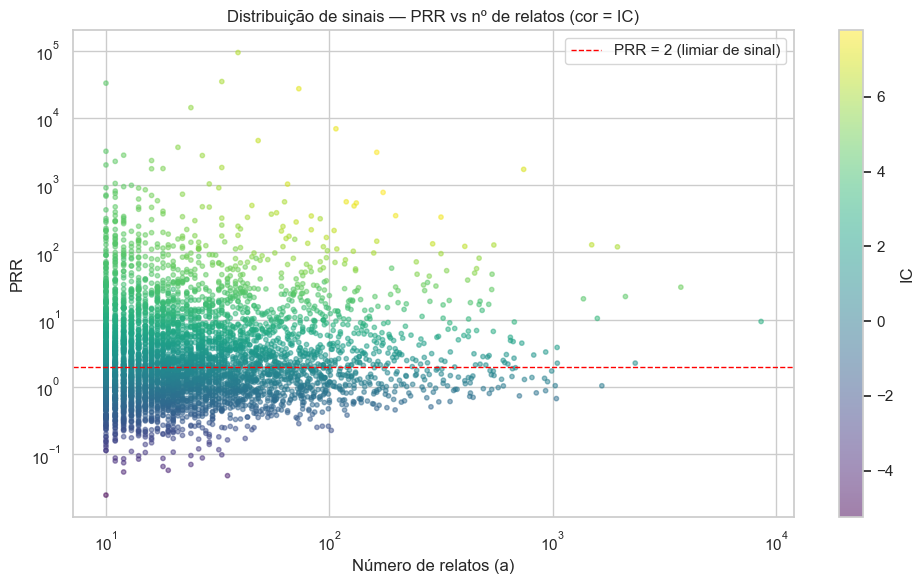

In [9]:
# Visualização: scatter PRR vs n_reports
fig, ax = plt.subplots(figsize=(10, 6))

sample = signals[signals["a"] >= 10].sample(min(5000, len(signals)), random_state=42)
ax.scatter(
    sample["a"], sample["prr"],
    c=sample["ic"], cmap="viridis",
    s=10, alpha=0.5,
)
ax.axhline(2, color="red", linestyle="--", linewidth=1, label="PRR = 2 (limiar de sinal)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Número de relatos (a)")
ax.set_ylabel("PRR")
ax.set_title("Distribuição de sinais — PRR vs nº de relatos (cor = IC)")
ax.legend()
plt.colorbar(ax.collections[0], label="IC")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_signal_scatter.png", bbox_inches="tight")
plt.show()

## 6. Salvar resultados

In [10]:
out_path = PROCESSED / "signals_2023.parquet"
signals.to_parquet(out_path, index=False)
print(f"✓ {out_path}  ({out_path.stat().st_size / 1e6:.1f} MB)")

long_path = PROCESSED / "long_2023.parquet"
long.to_parquet(long_path, index=False)
print(f"✓ {long_path}  ({long_path.stat().st_size / 1e6:.1f} MB)")

✓ C:\Katy\portfolio\farmacovigilancia-faers\data\processed\signals_2023.parquet  (25.9 MB)


✓ C:\Katy\portfolio\farmacovigilancia-faers\data\processed\long_2023.parquet  (42.8 MB)


## 7. Conclusões

- Sinais clássicos da literatura **foram recuperados** pelo método (validação ✓)
- Existem novos pares com IC025 muito alto que merecem investigação
- Trabalho pronto para alimentar o dashboard final (aba *Sinais*)

**Próximo notebook:** `04_severity_model.ipynb` — modelo XGBoost para prever se um caso será sério dado características do paciente e da droga.